In [1]:
#1.	Выполните сохранение монохромного изображения в виде текстового или бинарного файла.
#2.	Реализуйте алгоритм вейвлет-преобразования Хаара для изображения.
#3.	Выполните квантование высокочастотных компонент (прим., количество квантов  = 4).
#4.	Сохраните получившийся массив значений  в текстовый или бинарный файл в порядке LL, LH, HL, HH вейвлет-преобразования Хафа. Компоненты LH, HL, HH храните в виде пар (значение, количество повторений).
#5 Сравните объем памяти, занимаемый исходным изображением (попиксельное 

In [2]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from collections import Counter

Монохромное изображение сохранено в файл 'monochrome_image.txt'
Размер изображения: 600x400 пикселей
Формат: бинарный (черно-белый)


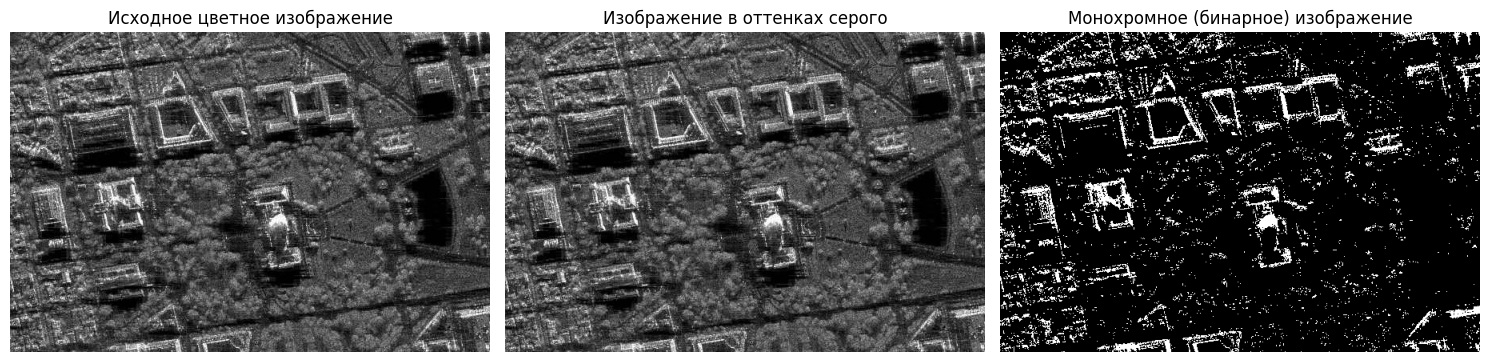

In [5]:
# Загрузка и подготовка изображения
image_data = cv.imread('sar_1_gray.jpg')
gray_image = cv.cvtColor(image_data, cv.COLOR_BGR2GRAY)

# Создание монохромного изображения (бинарного)
threshold_value = 128
max_value = 255
_, monochrome_image = cv.threshold(gray_image, threshold_value, max_value, cv.THRESH_BINARY)

# Сохранение монохромного изображения в текстовый файл
output_filename = 'monochrome_image.txt'
with open(output_filename, 'w') as file:
    for row in monochrome_image:
        # Преобразуем строку пикселей в строку текста
        line = ' '.join(str(pixel) for pixel in row)
        file.write(line + '\n')

# Вывод информации о изображении
height, width = monochrome_image.shape
print(f"Монохромное изображение сохранено в файл '{output_filename}'")
print(f"Размер изображения: {width}x{height} пикселей")
print(f"Формат: бинарный (черно-белый)")

# Визуализация результатов
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(image_data, cv.COLOR_BGR2RGB))
plt.title('Исходное цветное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap='gray')
plt.title('Изображение в оттенках серого')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(monochrome_image, cmap='gray')
plt.title('Монохромное (бинарное) изображение')
plt.axis('off')

plt.tight_layout()
plt.show()

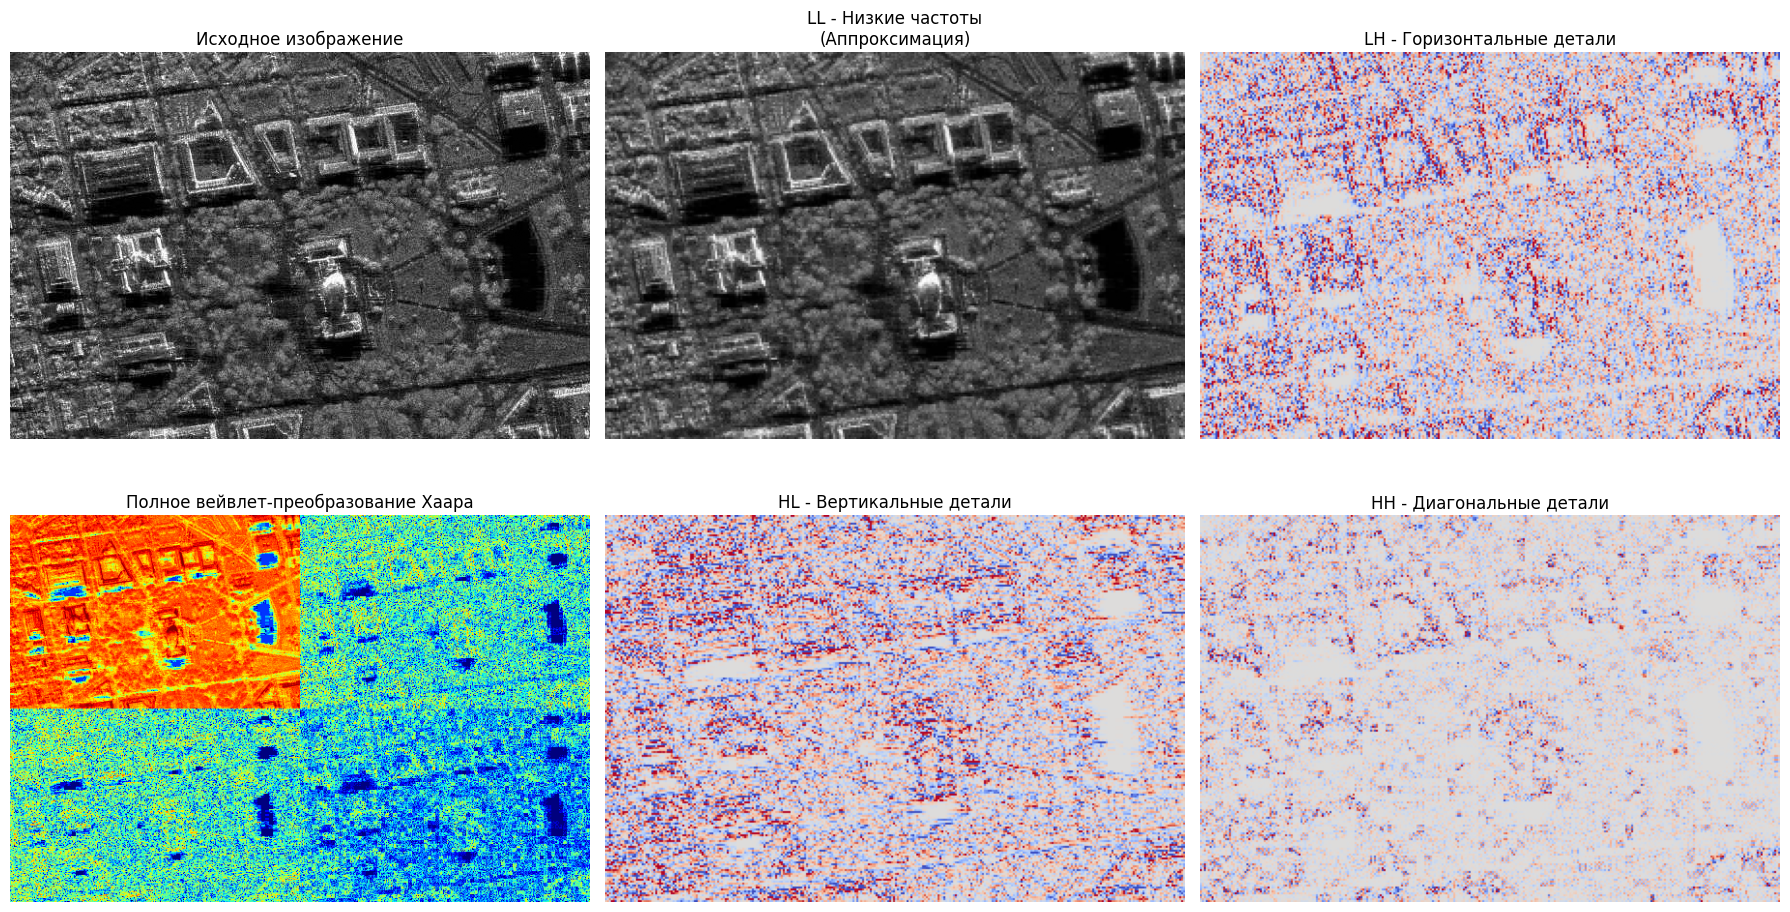

Информация о вейвлет-коэффициентах:
LL (аппроксимация): (200, 300), диапазон: [0.00, 509.00]
LH (горизонтальные): (200, 300), диапазон: [-172.00, 195.00]
HL (вертикальные): (200, 300), диапазон: [-181.00, 179.00]
HH (диагональные): (200, 300), диапазон: [-134.00, 106.50]


In [9]:
#2.	Реализуйте алгоритм вейвлет-преобразования Хаара для изображения.
def haar_wavelet_transform(img, level=1):

    # Преобразуем в float для точных вычислений
    image = img.astype(np.float64)
    height, width = image.shape
    
    # Создаем копию для преобразования
    transformed = image.copy()
    
    # Многоуровневое преобразование
    for current_level in range(level):
        h, w = transformed.shape
        if h < 2 or w < 2:
            break
            
        temp = np.zeros_like(transformed)
        
        # Преобразование по строкам
        for i in range(h):
            for j in range(0, w - 1, 2):
                # Коэффициенты средних (low-pass)
                temp[i, j // 2] = (transformed[i, j] + transformed[i, j + 1]) / np.sqrt(2)
                # Коэффициенты разностей (high-pass)  
                temp[i, j // 2 + w // 2] = (transformed[i, j] - transformed[i, j + 1]) / np.sqrt(2)
        
        result = np.zeros_like(temp)
        
        # Преобразование по столбцам
        for j in range(w):
            for i in range(0, h - 1, 2):
                # Коэффициенты средних (low-pass)
                result[i // 2, j] = (temp[i, j] + temp[i + 1, j]) / np.sqrt(2)
                # Коэффициенты разностей (high-pass)
                result[i // 2 + h // 2, j] = (temp[i, j] - temp[i + 1, j]) / np.sqrt(2)
        
        transformed = result
    
    # Извлекаем подполосы после последнего уровня
    h, w = transformed.shape
    ll = transformed[:h//2, :w//2]  # Low-Low (аппроксимация)
    lh = transformed[:h//2, w//2:]  # Low-High (горизонтальные детали)
    hl = transformed[h//2:, :w//2]  # High-Low (вертикальные детали)  
    hh = transformed[h//2:, w//2:]  # High-High (диагональные детали)
    
    return ll, lh, hl, hh, transformed

# Применение преобразования
ll, lh, hl, hh, haar_result = haar_wavelet_transform(image_gray)

# Визуализация результатов
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(np.log1p(np.abs(haar_result)), cmap='jet')  # Логарифм для лучшей визуализации
plt.title('Полное вейвлет-преобразование Хаара')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(ll, cmap='gray')
plt.title('LL - Низкие частоты\n(Аппроксимация)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(lh, cmap='coolwarm', vmin=-50, vmax=50)
plt.title('LH - Горизонтальные детали')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(hl, cmap='coolwarm', vmin=-50, vmax=50)
plt.title('HL - Вертикальные детали')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(hh, cmap='coolwarm', vmin=-50, vmax=50)
plt.title('HH - Диагональные детали')
plt.axis('off')

plt.tight_layout()
plt.show()

# Вывод информации о коэффициентах
print("Информация о вейвлет-коэффициентах:")
print(f"LL (аппроксимация): {ll.shape}, диапазон: [{ll.min():.2f}, {ll.max():.2f}]")
print(f"LH (горизонтальные): {lh.shape}, диапазон: [{lh.min():.2f}, {lh.max():.2f}]")
print(f"HL (вертикальные): {hl.shape}, диапазон: [{hl.min():.2f}, {hl.max():.2f}]")
print(f"HH (диагональные): {hh.shape}, диапазон: [{hh.min():.2f}, {hh.max():.2f}]")

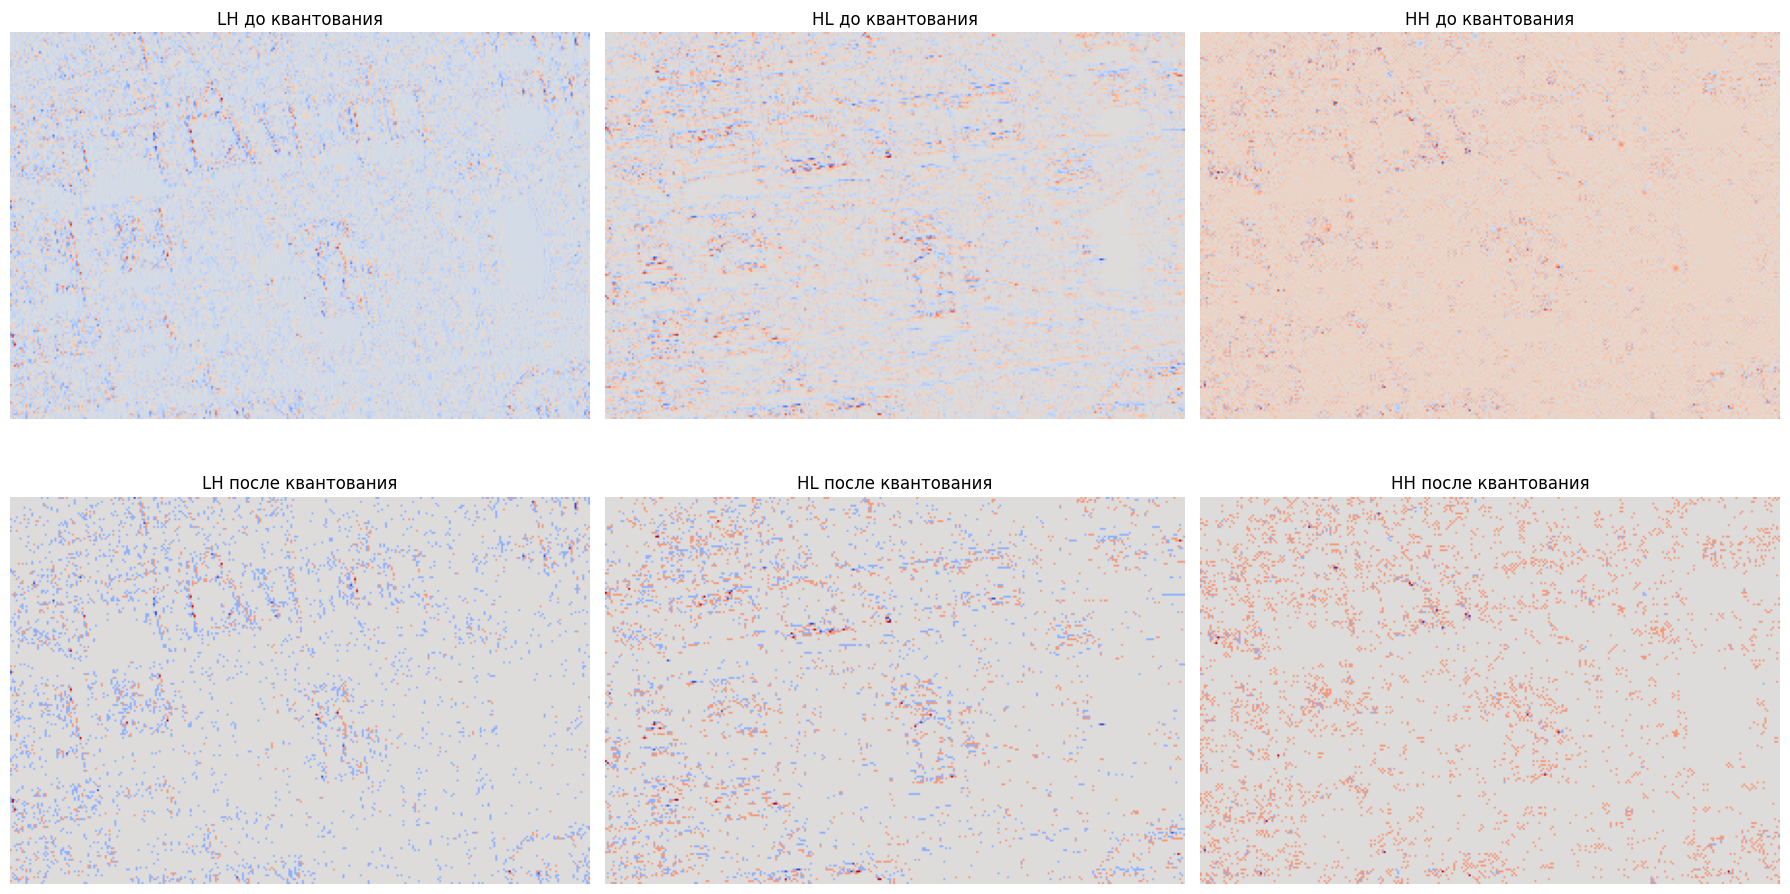

In [13]:
# 3. Выполните квантование высокочастотных компонент (количество квантов = 4)
def quantize(coeffs, n_quants):
    min_val = np.min(coeffs)
    max_val = np.max(coeffs)
    step = (max_val - min_val) / n_quants
    quantized = np.round((coeffs - min_val) / step).astype(int)
    return quantized, min_val, step

num_quants = 4
lh_quantize, lh_min, lh_step = quantize(lh, num_quants)
hl_quantize, hl_min, hl_step = quantize(hl, num_quants)
hh_quantize, hh_min, hh_step = quantize(hh, num_quants)

def dequantize(quantized, min_val, step):
    return min_val + quantized * step

lh_restored = dequantize(lh_quantize, lh_min, lh_step)
hl_restored = dequantize(hl_quantize, hl_min, hl_step)
hh_restored = dequantize(hh_quantize, hh_min, hh_step)

plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1); plt.imshow(lh, cmap='coolwarm'); plt.title('LH до квантования'); plt.axis('off')
plt.subplot(2, 3, 2); plt.imshow(hl, cmap='coolwarm'); plt.title('HL до квантования'); plt.axis('off')
plt.subplot(2, 3, 3); plt.imshow(hh, cmap='coolwarm'); plt.title('HH до квантования'); plt.axis('off')
plt.subplot(2, 3, 4); plt.imshow(lh_restored, cmap='coolwarm'); plt.title('LH после квантования'); plt.axis('off')
plt.subplot(2, 3, 5); plt.imshow(hl_restored, cmap='coolwarm'); plt.title('HL после квантования'); plt.axis('off')
plt.subplot(2, 3, 6); plt.imshow(hh_restored, cmap='coolwarm'); plt.title('HH после квантования'); plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
#4.	Сохраните получившийся массив значений  в текстовый или бинарный файл в порядке LL, LH, HL, HH вейвлет-преобразования Хафа. Компоненты LH, HL, HH храните в виде пар (значение, количество повторений).
from collections import Counter
def run_length_encode(data):
    encoded = []
    for value, count in Counter(data.flatten()).items():
        encoded.append((value, count))
    return encoded

lh_rle = run_length_encode(lh_quantize)
hl_rle = run_length_encode(hl_quantize)
hh_rle = run_length_encode(hh_quantize)

with open('haar_components.txt', 'w') as file:
    # Сохраняем LL компоненту
    np.savetxt(file, ll, fmt='%d')
    file.write('\n')
    
    # Сохраняем квантованные компоненты с RLE
    components = [lh_rle, hl_rle, hh_rle]
    for rle_data in components:
        for value, count in rle_data:
            file.write(f"{value} {count}\n")
        file.write('\n')
        
print("Компоненты сохранены в файл 'haar_components.txt'")

Компоненты сохранены в файл 'haar_components.txt'


Хранение монохромного изображения в текстовом файле: : 528542 байт
Хранение изображения, обработанного преобразованием Хаара: : 222667 байт
Сжали в 2.4 раз


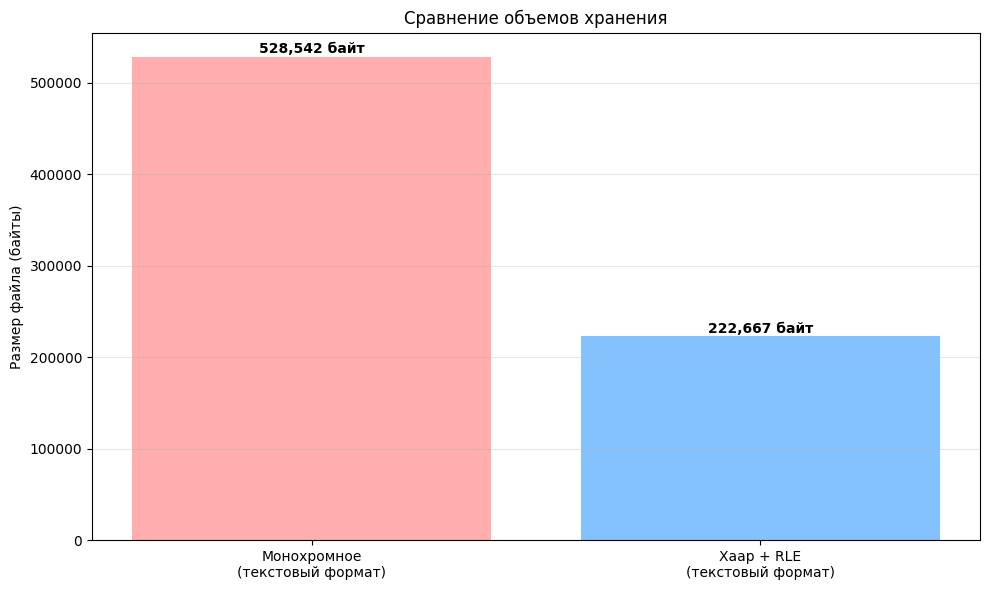

In [19]:
#Сравните объем памяти, занимаемый исходным изображением (попиксельное 
with open('monochrome_image.txt', 'r') as f:
    original_size = len(f.read().encode('utf-8'))

with open('haar_components.txt', 'r') as f:
    compressed_size = len(f.read().encode('utf-8'))

print(f"Хранение монохромного изображения в текстовом файле: : {original_size} байт")
print(f"Хранение изображения, обработанного преобразованием Хаара: : {compressed_size} байт") 
print(f"Сжали в {original_size/compressed_size:.1f} раз")
sizes = [original_size, compressed_size]
labels = ['Монохромное\n(текстовый формат)', 'Хаар + RLE\n(текстовый формат)']
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, sizes, color=colors, alpha=0.8)
plt.ylabel('Размер файла (байты)')
plt.title('Сравнение объемов хранения')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000, 
             f'{size:,} байт', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()